In [22]:
from pathlib import Path
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

In [23]:
CWD = Path.cwd()
DATA = CWD / "data"

In [24]:
df_tweets = pd.read_csv(DATA / 'tweets.csv')
df_users = pd.read_csv(DATA / 'users.csv')

In [25]:
df_tweets

,user_id,user_key,created_at,created_str,retweet_count,retweeted,favorite_count,text,tweet_id,source,hashtags,expanded_urls,posted,mentions,retweeted_status_id,in_reply_to_status_id
0,2.532612e+09,kathiemrr,1.488207e+12,2017-02-27 14:54:00,NaN,NaN,NaN,#ThingsDoneByMistake kissing auntie in the lips,8.362279e+17,NaN,"[""ThingsDoneByMistake""]",[],POSTED,[],NaN,NaN
1,2.531160e+09,traceyhappymom,1.471273e+12,2016-08-15 14:50:20,NaN,NaN,NaN,RT @mc_derpin: #TheOlderWeGet the more pessimi...,7.651989e+17,NaN,"[""TheOlderWeGet""]",[],POSTED,[],NaN,NaN
2,NaN,evewebster373,1.435701e+12,2015-06-30 21:56:09,NaN,NaN,NaN,RT @dmataconis: Ready To Feel Like A Failure? ...,6.160023e+17,NaN,[],[],POSTED,[],NaN,NaN
3,4.840552e+09,blacktolive,1.474013e+12,2016-09-16 08:04:48,18.0,False,17.0,Amen! #blacklivesmatter https://t.co/wGffaOqgzl,7.766933e+17,"<a href=""http://twitter.com"" rel=""nofollow"">Tw...","[""Blacklivesmatter""]",[],POSTED,[],NaN,NaN
4,1.694026e+09,jacquelinisbest,1.474228e+12,2016-09-18 19:46:25,0.0,False,0.0,RT @NahBabyNah: Twitchy: Chuck Todd caught out...,7.775946e+17,"<a href=""http://twitter.com"" rel=""nofollow"">Tw...","[""WakeUpAmerica""]","[""http://ln.is/twitchy.com/loriz-31/3yafU""]",POSTED,"[""nahbabynah""]",7.775915e+17,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203446,1.710805e+09,cookncooks,1.480735e+12,2016-12-03 03:16:17,NaN,NaN,NaN,RT @FairyTale_360: 6) Rexnord Bearings is set ...,8.048869e+17,NaN,[],[],POSTED,[],NaN,NaN
203447,2.928870e+09,newspeakdaily,1.475279e+12,2016-09-30 23:39:11,0.0,False,0.0,Will Trump’s Bad Week Hurt the GOP’s Senate Pr...,7.820019e+17,"<a href=""http://twitterfeed.com"" rel=""nofollow...","[""Politics""]",[],POSTED,[],NaN,NaN
203448,2.951556e+09,specialaffair,1.473072e+12,2016-09-05 10:45:09,0.0,False,0.0,"China blames United States, journalists for Ob...",7.727474e+17,"<a href=""http://twitterfeed.com"" rel=""nofollow...","[""news""]",[],POSTED,[],NaN,NaN
203449,2.671070e+09,patriotblake,1.486385e+12,2017-02-06 12:36:14,NaN,NaN,NaN,RT @bfraser747: 💥💥 #PresidentElectTrump \r\n\r...,8.285831e+17,NaN,[],[],POSTED,[],NaN,NaN


In [26]:
df_users

,id,location,name,followers_count,statuses_count,time_zone,verified,lang,screen_name,description,created_at,favourites_count,friends_count,listed_count
0,100345056.0,still ⬆️Block⤵️Corner⬇️street,#Ezekiel2517✨...,1053.0,31858.0,NaN,False,en,SCOTTGOHARD,CELEBRITY TRAINER ✨#424W147th✨ #CrossfitCoach ...,Tue Dec 29 23:15:22 +0000 2009,2774.0,1055.0,35.0
1,247165706.0,"Chicago, IL",B E C K S T E R✨,650.0,6742.0,Mountain Time (US & Canada),False,en,Beckster319,Rebecca Lynn Hirschfeld Actress.Model.Writer.A...,Fri Feb 04 06:38:45 +0000 2011,7273.0,896.0,30.0
2,249538861.0,NaN,Chris Osborne,44.0,843.0,NaN,False,en,skatewake1994,NaN,Wed Feb 09 07:38:44 +0000 2011,227.0,154.0,1.0
3,449689677.0,NaN,Рамзан Кадыров,94773.0,10877.0,Moscow,False,ru,KadirovRussia,"Пародийный аккаунт. Озвучиваю то, что политика...",Thu Dec 29 11:31:09 +0000 2011,0.0,7.0,691.0
4,471868887.0,"Санкт-Петербург, Россия",Маргарита Саваж,23305.0,18401.0,Volgograd,False,ru,MargoSavazh,Честь имею. Нагло врать не умею.,Mon Jan 23 10:26:25 +0000 2012,1480.0,8021.0,231.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ReachItDoIt,NaN,NaN,NaN,NaN,NaN
449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KirstenLaDaniel,NaN,NaN,NaN,NaN,NaN
450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gwen_garland,NaN,NaN,NaN,NaN,NaN
451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KlausFinker,NaN,NaN,NaN,NaN,NaN


In [27]:
print(f"Users dataframe columns:\n {df_users.columns}\n")
print(f"Tweets dataframe columns:\n {df_tweets.columns}")

Users dataframe columns:
 Index(['id', 'location', 'name', 'followers_count', 'statuses_count',
       'time_zone', 'verified', 'lang', 'screen_name', 'description',
       'created_at', 'favourites_count', 'friends_count', 'listed_count'],
      dtype='object')

Tweets dataframe columns:
 Index(['user_id', 'user_key', 'created_at', 'created_str', 'retweet_count',
       'retweeted', 'favorite_count', 'text', 'tweet_id', 'source', 'hashtags',
       'expanded_urls', 'posted', 'mentions', 'retweeted_status_id',
       'in_reply_to_status_id'],
      dtype='object')


In [28]:
def create_graph(all_nodes):
    G = nx.DiGraph()

    for _, user in df_users.iterrows():
        G.add_node(user['screen_name'].lower())

    def update_edge(graph, src, dest):
        if graph.has_edge(src, dest):
            graph[src][dest]['weight'] += 1
        else:
            graph.add_edge(src, dest, weight=1)

    for _, tweet in df_tweets.iterrows():
        mentions_string = tweet['mentions']
        if (mentions_string != "[]"):
            mentions_string = mentions_string[2: -2]
            mentions_list = mentions_string.split('","')

            for mention in mentions_list:
                source = tweet['user_key']
                target = mention

                if all_nodes:
                    update_edge(G, source, target)
                else:
                    if target in G.nodes() and source in G.nodes():
                        update_edge(G, source, target)
    return G

In [29]:
G_trolls = create_graph(all_nodes=False)
G_overall = create_graph(all_nodes=True)

In [30]:
def print_basic_graph_info(G, name):
    print(f"Basic information about {name} Graph")
    print(f"Number of users (nodes): {G.number_of_nodes()}.")
    print(f"Number of mentions (edges): {G.number_of_edges()}")

In [31]:
print_basic_graph_info(G_trolls, "Only Trolls")

Basic information about Only Trolls Graph
Number of users (nodes): 453.
Number of mentions (edges): 290


In [32]:
print_basic_graph_info(G_overall, "All Mentioned Users")

Basic information about All Mentioned Users Graph
Number of users (nodes): 14273.
Number of mentions (edges): 33180


In [33]:
def plot_degree_distributions(G_trolls, G_overall):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Trolls graph - In-degree
    in_degrees_t = [d for n, d in G_trolls.in_degree()]
    in_vals_t = sorted(set(in_degrees_t))
    in_counts_t = [in_degrees_t.count(v) for v in in_vals_t]
    min_val_t = min(in_vals_t)
    max_val_t = max(in_vals_t)
    avg_val_t = np.mean(in_degrees_t)

    axes[0].bar(in_vals_t, in_counts_t, alpha=0.7, color='skyblue')
    axes[0].set_xlabel('In-degree')
    axes[0].set_ylabel('Frequency (log scale)')
    axes[0].set_yscale('log')
    axes[0].set_title('Only Troll Users: In-degree Distribution (Most Mentioned Users)')
    axes[0].set_xlim(min_val_t - 0.5, max_val_t + 0.5)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend([f'Min: {min_val_t}\nMax: {max_val_t}\nAvg: {avg_val_t:.2f}'],
                   loc='upper right')

    # Overall graph - In-degree
    in_degrees_o = [d for n, d in G_overall.in_degree()]
    in_vals_o = sorted(set(in_degrees_o))
    in_counts_o = [in_degrees_o.count(v) for v in in_vals_o]
    min_val_o = min(in_vals_o)
    max_val_o = max(in_vals_o)
    avg_val_o = np.mean(in_degrees_o)

    axes[1].bar(in_vals_o, in_counts_o, alpha=0.7, color='skyblue')
    axes[1].set_xlabel('In-degree')
    axes[1].set_ylabel('Frequency (log scale)')
    axes[1].set_yscale('log')
    axes[1].set_title('All Users: In-degree Distribution (Most Mentioned Users)')
    axes[1].set_xlim(min_val_o - 0.5, max_val_o + 0.5)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend([f'Min: {min_val_o}\nMax: {max_val_o}\nAvg: {avg_val_o:.2f}'],
                   loc='upper right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/in_degree_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Out-degree distributions
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Trolls graph - Out-degree
    out_degrees_t = [d for n, d in G_trolls.out_degree()]
    out_vals_t = sorted(set(out_degrees_t))
    out_counts_t = [out_degrees_t.count(v) for v in out_vals_t]
    min_val_t = min(out_vals_t)
    max_val_t = max(out_vals_t)
    avg_val_t = np.mean(out_degrees_t)

    axes[0].bar(out_vals_t, out_counts_t, alpha=0.7, color='lightcoral')
    axes[0].set_xlabel('Out-degree')
    axes[0].set_ylabel('Frequency (log scale)')
    axes[0].set_yscale('log')
    axes[0].set_title('Only Troll Users: Out-degree Distribution (Most Active Mentioners)')
    axes[0].set_xlim(min_val_t - 0.5, max_val_t + 0.5)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend([f'Min: {min_val_t}\nMax: {max_val_t}\nAvg: {avg_val_t:.2f}'],
                   loc='upper right')

    # Overall graph - Out-degree
    out_degrees_o = [d for n, d in G_overall.out_degree()]
    out_vals_o = sorted(set(out_degrees_o))
    out_counts_o = [out_degrees_o.count(v) for v in out_vals_o]
    min_val_o = min(out_vals_o)
    max_val_o = max(out_vals_o)
    avg_val_o = np.mean(out_degrees_o)

    axes[1].bar(out_vals_o, out_counts_o, alpha=0.7, color='lightcoral')
    axes[1].set_xlabel('Out-degree')
    axes[1].set_ylabel('Frequency (log scale)')
    axes[1].set_yscale('log')
    axes[1].set_title('All Users: Out-degree Distribution (Most Active Mentioners')
    axes[1].set_xlim(min_val_o - 0.5, max_val_o + 0.5)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend([f'Min: {min_val_o}\nMax: {max_val_o}\nAvg: {avg_val_o:.2f}'],
                   loc='upper right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/out_degree_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

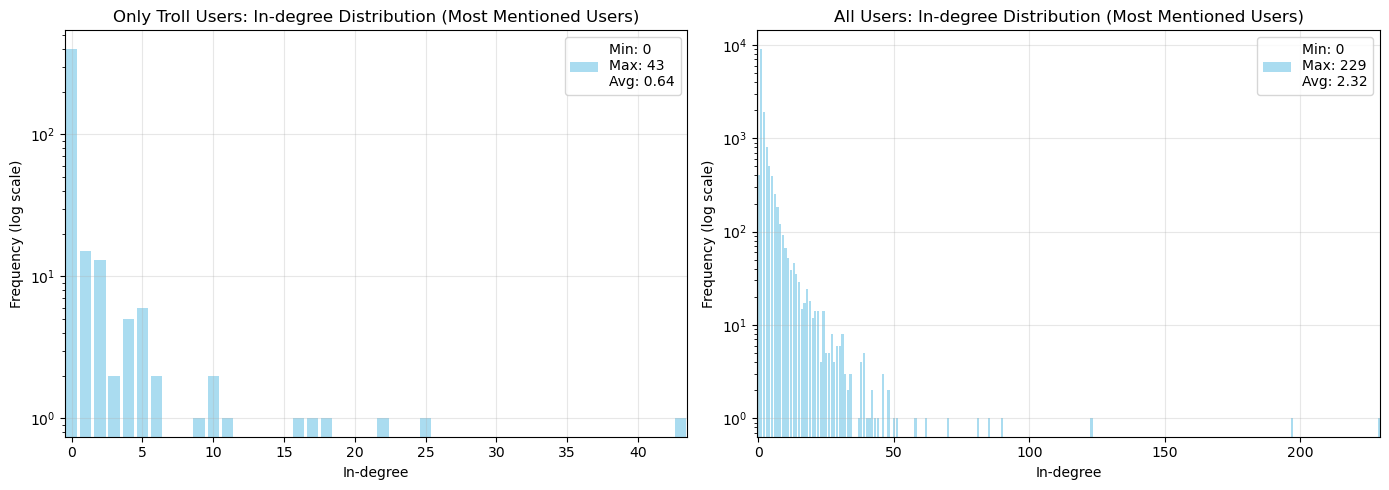

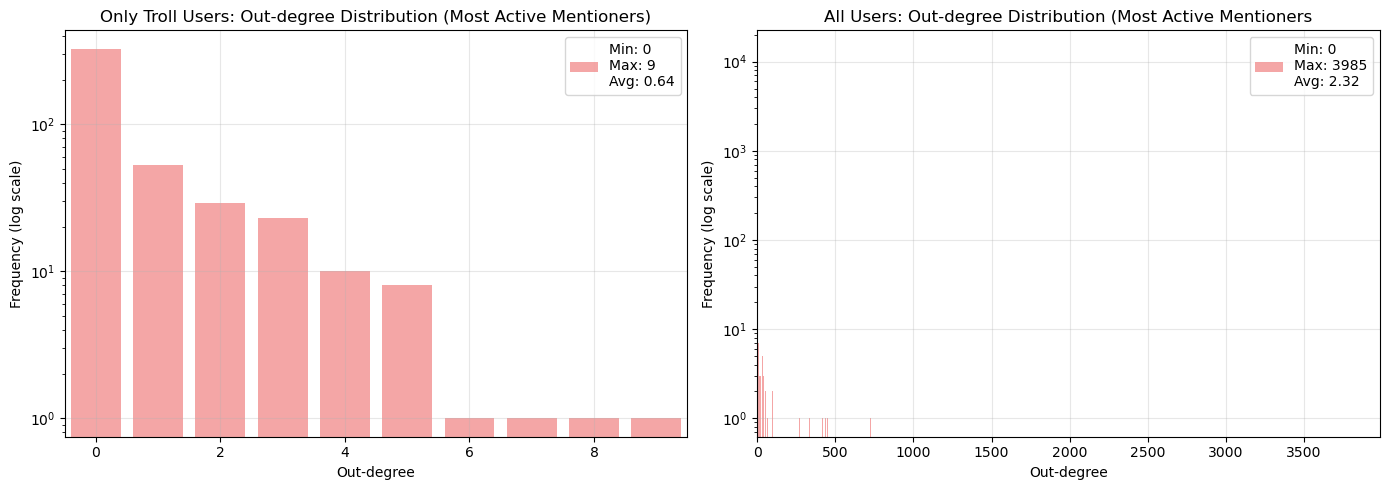

In [34]:
plot_degree_distributions(G_trolls, G_overall)

In [35]:
def plot_weight_distribution(G_trolls, G_overall):
    weights_t = [data['weight'] for _, _, data in G_trolls.edges(data=True)]
    weights_o = [data['weight'] for _, _, data in G_overall.edges(data=True)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Trolls - Histogram
    min_val_t = min(weights_t)
    max_val_t = max(weights_t)
    avg_val_t = np.mean(weights_t)

    axes[0].hist(weights_t, bins=30, alpha=0.7, color='mediumseagreen', edgecolor='black')
    axes[0].set_xlabel('Edge Weight')
    axes[0].set_ylabel('Frequency (log scale)')
    axes[0].set_yscale('log')
    axes[0].set_title('Trolls: Edge Weight Distribution')
    axes[0].set_xlim(min_val_t - 0.5, max_val_t + 0.5)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend([f'Min: {min_val_t}\nMax: {max_val_t}\nAvg: {avg_val_t:.2f}'],
                   loc='upper right')

    # Overall - Histogram
    min_val_o = min(weights_o)
    max_val_o = max(weights_o)
    avg_val_o = np.mean(weights_o)

    axes[1].hist(weights_o, bins=30, alpha=0.7, color='mediumseagreen', edgecolor='black')
    axes[1].set_xlabel('Edge Weight')
    axes[1].set_ylabel('Frequency (log scale)')
    axes[1].set_yscale('log')
    axes[1].set_title('Overall: Edge Weight Distribution')
    axes[1].set_xlim(min_val_o - 0.5, max_val_o + 0.5)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend([f'Min: {min_val_o}\nMax: {max_val_o}\nAvg: {avg_val_o:.2f}'],
                   loc='upper right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/weight_distribution_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Log-log plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    weight_counter_t = Counter(weights_t)
    x_vals_t = sorted(weight_counter_t.keys())
    y_vals_t = [weight_counter_t[x] for x in x_vals_t]
    min_val_t = min(x_vals_t)
    max_val_t = max(x_vals_t)

    axes[0].loglog(x_vals_t, y_vals_t, 'bo', alpha=0.6)
    axes[0].set_xlabel('Weight (log scale)')
    axes[0].set_ylabel('Frequency (log scale)')
    axes[0].set_title('Trolls: Weight Distribution (Log-Log)')
    axes[0].set_xlim(min_val_t * 0.9, max_val_t * 1.1)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend([f'Min: {min_val_t}\nMax: {max_val_t}'],
                   loc='upper right')

    weight_counter_o = Counter(weights_o)
    x_vals_o = sorted(weight_counter_o.keys())
    y_vals_o = [weight_counter_o[x] for x in x_vals_o]
    min_val_o = min(x_vals_o)
    max_val_o = max(x_vals_o)

    axes[1].loglog(x_vals_o, y_vals_o, 'bo', alpha=0.6)
    axes[1].set_xlabel('Weight (log scale)')
    axes[1].set_ylabel('Frequency (log scale)')
    axes[1].set_title('Overall: Weight Distribution (Log-Log)')
    axes[1].set_xlim(min_val_o * 0.9, max_val_o * 1.1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend([f'Min: {min_val_o}\nMax: {max_val_o}'],
                   loc='upper right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/weight_distribution_loglog.png', dpi=300, bbox_inches='tight')
    plt.show()

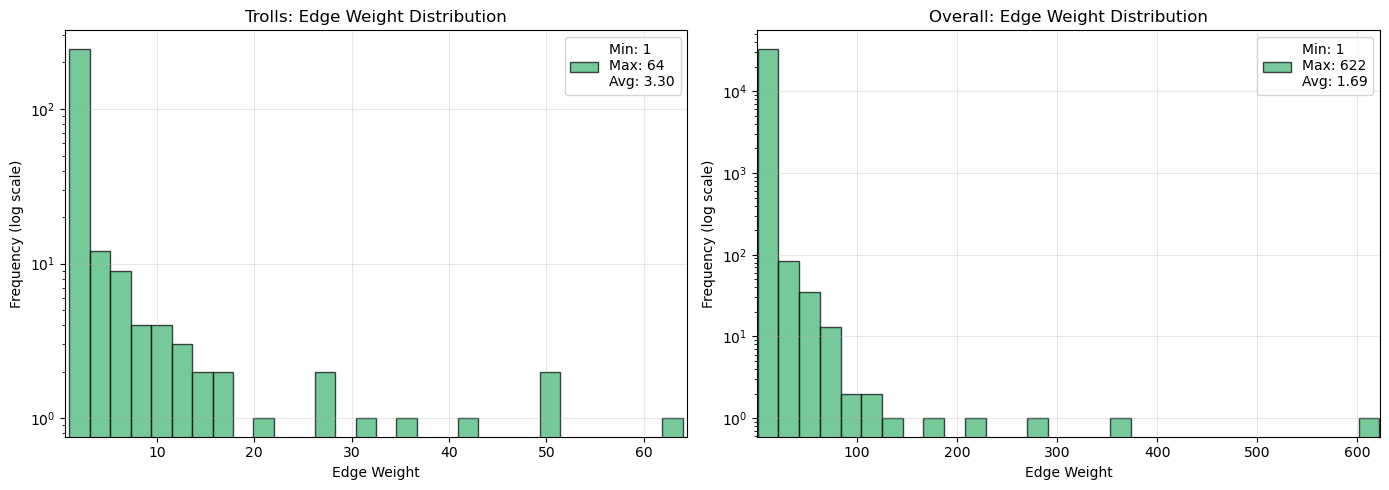

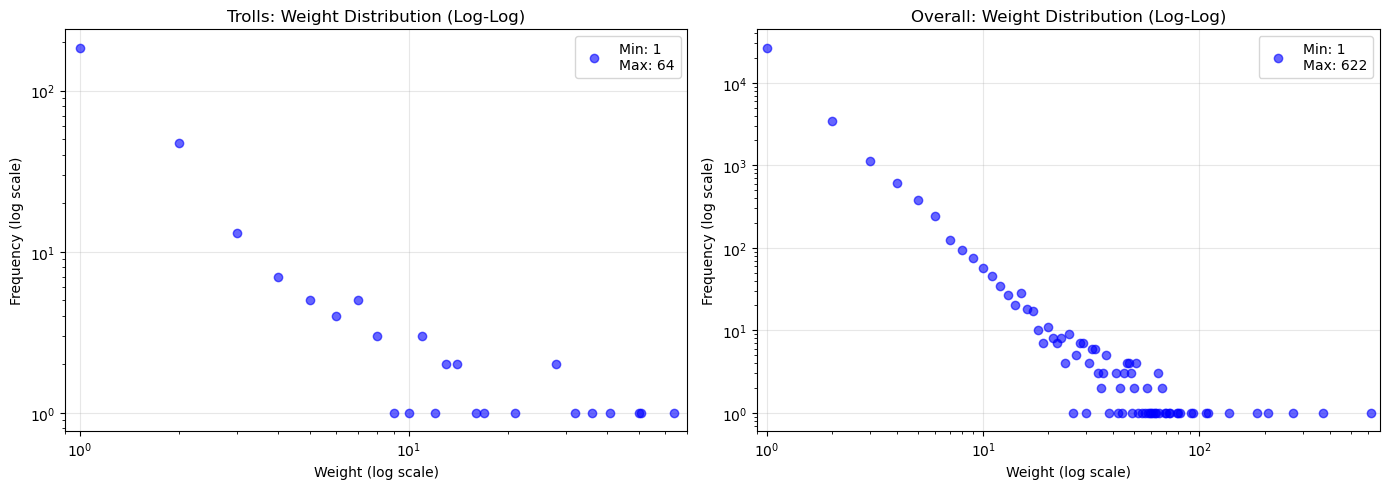

In [36]:
plot_weight_distribution(G_trolls, G_overall)

In [37]:
def plot_centrality_measures(G_trolls, G_overall):

    # Degree Centrality
    degree_centrality_t = nx.degree_centrality(G_trolls)
    degree_centrality_o = nx.degree_centrality(G_overall)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    deg_values_t = list(degree_centrality_t.values())
    min_val_t = min(deg_values_t)
    max_val_t = max(deg_values_t)
    avg_val_t = np.mean(deg_values_t)

    axes[0].hist(deg_values_t, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Degree Centrality')
    axes[0].set_ylabel('Frequency (log scale)')
    axes[0].set_yscale('log')
    axes[0].set_title('Trolls: Degree Centrality Distribution')
    axes[0].set_xlim(min_val_t - 0.01, max_val_t + 0.01)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend([f'Min: {min_val_t:.4f}\nMax: {max_val_t:.4f}\nAvg: {avg_val_t:.4f}'],
                   loc='upper right')

    deg_values_o = list(degree_centrality_o.values())
    min_val_o = min(deg_values_o)
    max_val_o = max(deg_values_o)
    avg_val_o = np.mean(deg_values_o)

    axes[1].hist(deg_values_o, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].set_xlabel('Degree Centrality')
    axes[1].set_ylabel('Frequency (log scale)')
    axes[1].set_yscale('log')
    axes[1].set_title('Overall: Degree Centrality Distribution')
    axes[1].set_xlim(min_val_o - 0.01, max_val_o + 0.01)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend([f'Min: {min_val_o:.4f}\nMax: {max_val_o:.4f}\nAvg: {avg_val_o:.4f}'],
                   loc='upper right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/degree_centrality_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    # PageRank
    pagerank_t = nx.pagerank(G_trolls, weight='weight')
    pagerank_o = nx.pagerank(G_overall, weight='weight')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    pr_values_t = list(pagerank_t.values())
    min_val_t = min(pr_values_t)
    max_val_t = max(pr_values_t)
    avg_val_t = np.mean(pr_values_t)

    axes[0].hist(pr_values_t, bins=30, alpha=0.7, color='coral', edgecolor='black')
    axes[0].set_xlabel('PageRank')
    axes[0].set_ylabel('Frequency (log scale)')
    axes[0].set_yscale('log')
    axes[0].set_title('Trolls: PageRank Distribution')
    axes[0].set_xlim(min_val_t * 0.9, max_val_t * 1.1)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend([f'Min: {min_val_t:.4f}\nMax: {max_val_t:.4f}\nAvg: {avg_val_t:.4f}'],
                   loc='upper right')

    pr_values_o = list(pagerank_o.values())
    min_val_o = min(pr_values_o)
    max_val_o = max(pr_values_o)
    avg_val_o = np.mean(pr_values_o)

    axes[1].hist(pr_values_o, bins=30, alpha=0.7, color='coral', edgecolor='black')
    axes[1].set_xlabel('PageRank')
    axes[1].set_ylabel('Frequency (log scale)')
    axes[1].set_yscale('log')
    axes[1].set_title('Overall: PageRank Distribution')
    axes[1].set_xlim(min_val_o * 0.9, max_val_o * 1.1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend([f'Min: {min_val_o:.4f}\nMax: {max_val_o:.4f}\nAvg: {avg_val_o:.4f}'],
                   loc='upper right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/pagerank_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

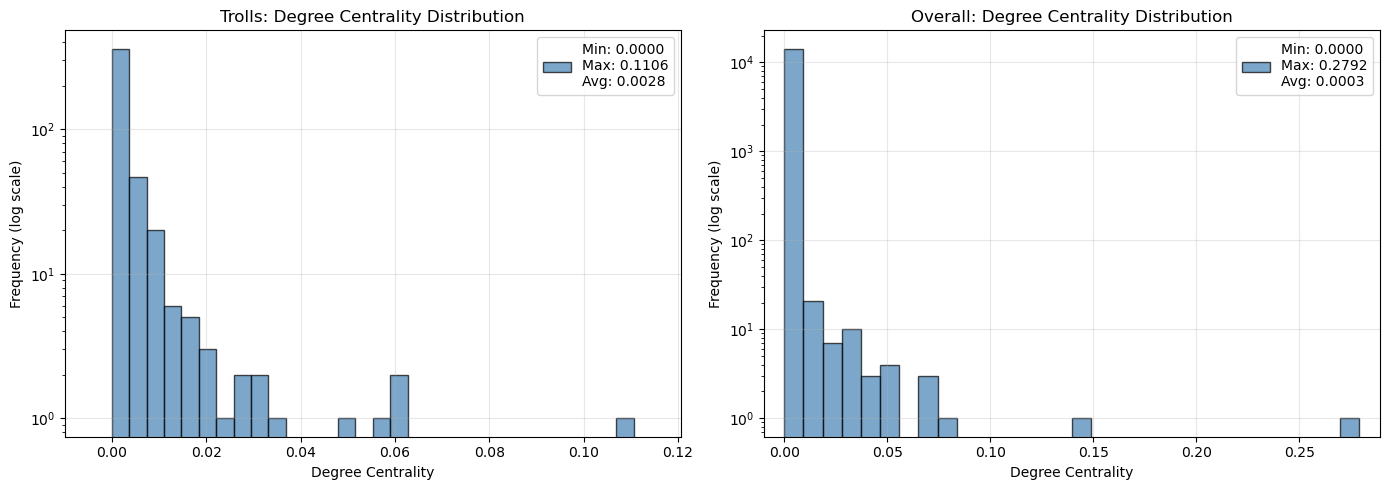

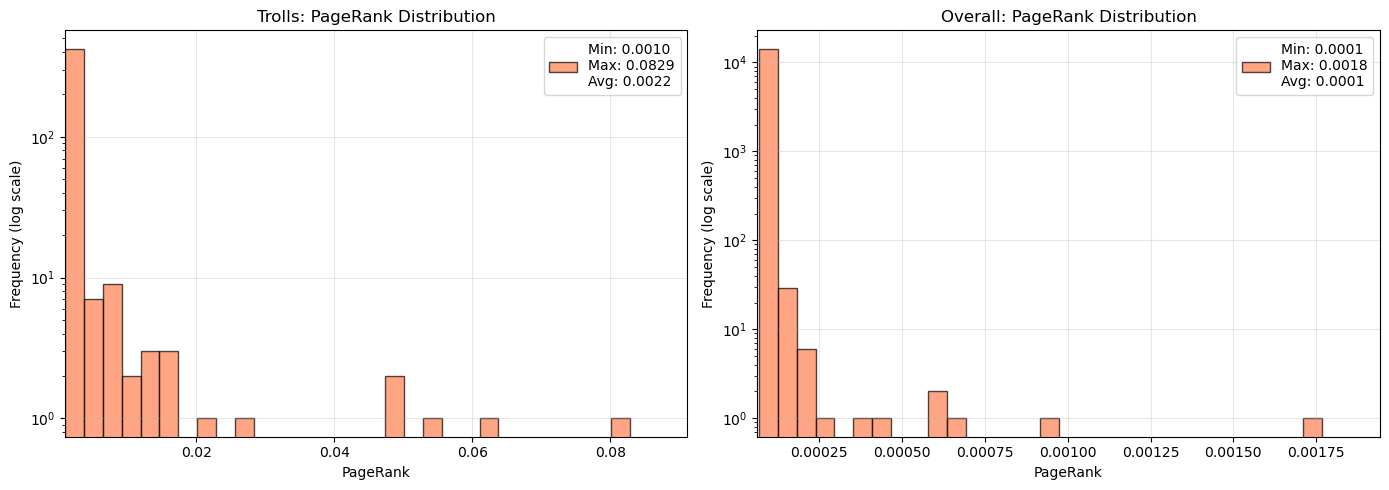

In [38]:
plot_centrality_measures(G_trolls, G_overall)

In [39]:
def plot_top_users_bar_charts(G_trolls, G_overall, top_n=20):

    # Top by in-degree
    in_degrees_t = dict(G_trolls.in_degree())
    in_degrees_o = dict(G_overall.in_degree())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_in_t = sorted(in_degrees_t.items(), key=lambda x: x[1], reverse=True)[:top_n]
    users_in_t, degs_in_t = zip(*top_in_t)
    axes[0].barh(range(len(users_in_t)), degs_in_t, color='lightblue')
    axes[0].set_yticks(range(len(users_in_t)))
    axes[0].set_yticklabels(users_in_t, fontsize=9)
    axes[0].set_xlabel('In-degree')
    axes[0].set_title(f'Top {top_n} Troll Users by In-degree (Most Mentioned Users)')
    axes[0].invert_yaxis()
    axes[0].legend(['Most Mentioned Users'], loc='lower right')

    top_in_o = sorted(in_degrees_o.items(), key=lambda x: x[1], reverse=True)[:top_n]
    users_in_o, degs_in_o = zip(*top_in_o)
    axes[1].barh(range(len(users_in_o)), degs_in_o, color='lightblue')
    axes[1].set_yticks(range(len(users_in_o)))
    axes[1].set_yticklabels(users_in_o, fontsize=9)
    axes[1].set_xlabel('In-degree')
    axes[1].set_title(f'Top {top_n} Overall Users by In-degree (Most Mentioned Users)')
    axes[1].invert_yaxis()
    axes[1].legend(['Most Mentioned Users'], loc='lower right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/top_{top_n}_by_in_degree.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Top by out-degree
    out_degrees_t = dict(G_trolls.out_degree())
    out_degrees_o = dict(G_overall.out_degree())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_out_t = sorted(out_degrees_t.items(), key=lambda x: x[1], reverse=True)[:top_n]
    users_out_t, degs_out_t = zip(*top_out_t)
    axes[0].barh(range(len(users_out_t)), degs_out_t, color='lightcoral')
    axes[0].set_yticks(range(len(users_out_t)))
    axes[0].set_yticklabels(users_out_t, fontsize=9)
    axes[0].set_xlabel('Out-degree')
    axes[0].set_title(f'Top {top_n} Troll Users by Out-degree (Most Active Mentioners)')
    axes[0].invert_yaxis()
    axes[0].legend(['Most Active Mentioners'], loc='lower right')

    top_out_o = sorted(out_degrees_o.items(), key=lambda x: x[1], reverse=True)[:top_n]
    users_out_o, degs_out_o = zip(*top_out_o)
    axes[1].barh(range(len(users_out_o)), degs_out_o, color='lightcoral')
    axes[1].set_yticks(range(len(users_out_o)))
    axes[1].set_yticklabels(users_out_o, fontsize=9)
    axes[1].set_xlabel('Out-degree')
    axes[1].set_title(f'Top {top_n} Overall Users by Out-degree (Most Active Mentioners')
    axes[1].invert_yaxis()
    axes[1].legend(['Most Active Mentioners'], loc='lower right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/top_{top_n}_by_out_degree.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Top by PageRank
    pagerank_t = nx.pagerank(G_trolls, weight='weight')
    pagerank_o = nx.pagerank(G_overall, weight='weight')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_pr_t = sorted(pagerank_t.items(), key=lambda x: x[1], reverse=True)[:top_n]
    users_pr_t, vals_pr_t = zip(*top_pr_t)
    axes[0].barh(range(len(users_pr_t)), vals_pr_t, color='lightgreen')
    axes[0].set_yticks(range(len(users_pr_t)))
    axes[0].set_yticklabels(users_pr_t, fontsize=9)
    axes[0].set_xlabel('PageRank')
    axes[0].set_title(f'Top {top_n} Troll Users by PageRank')
    axes[0].invert_yaxis()
    axes[0].legend(['Users by PageRank'], loc='lower right')

    top_pr_o = sorted(pagerank_o.items(), key=lambda x: x[1], reverse=True)[:top_n]
    users_pr_o, vals_pr_o = zip(*top_pr_o)
    axes[1].barh(range(len(users_pr_o)), vals_pr_o, color='lightgreen')
    axes[1].set_yticks(range(len(users_pr_o)))
    axes[1].set_yticklabels(users_pr_o, fontsize=9)
    axes[1].set_xlabel('PageRank')
    axes[1].set_title(f'Top {top_n} Overall Users by PageRank')
    axes[1].invert_yaxis()
    axes[1].legend(['Users by PageRank'], loc='lower right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/top_{top_n}_by_pagerank.png', dpi=300, bbox_inches='tight')
    plt.show()

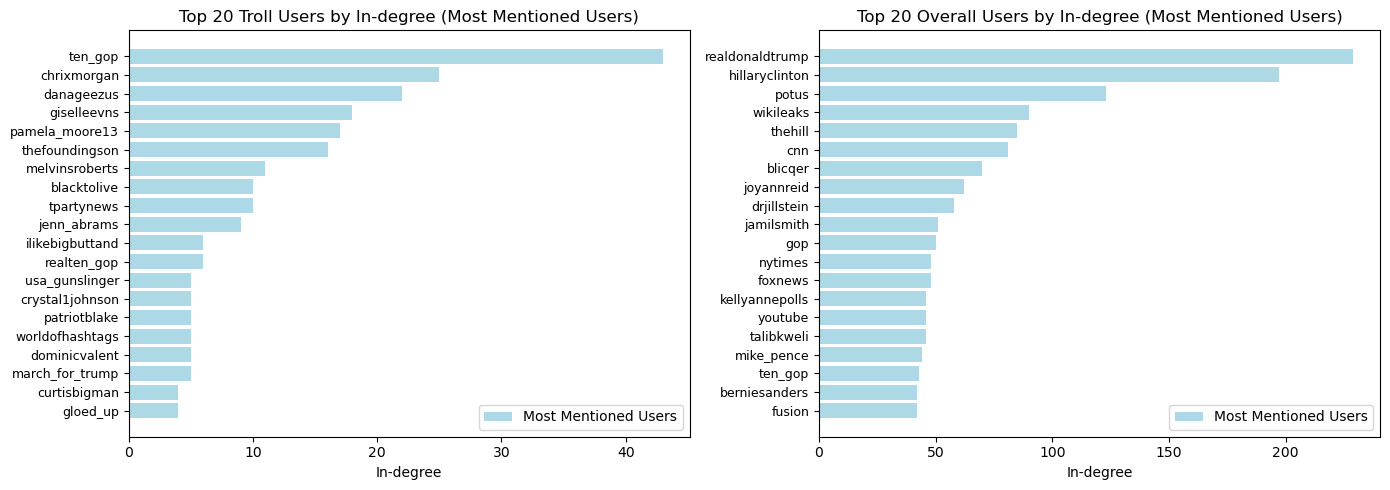

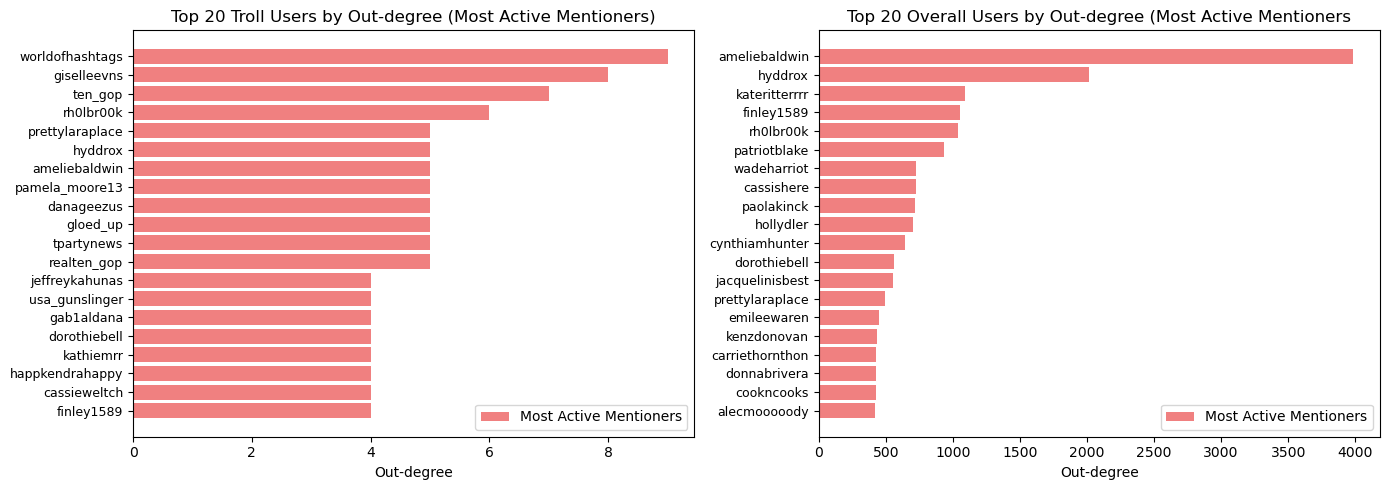

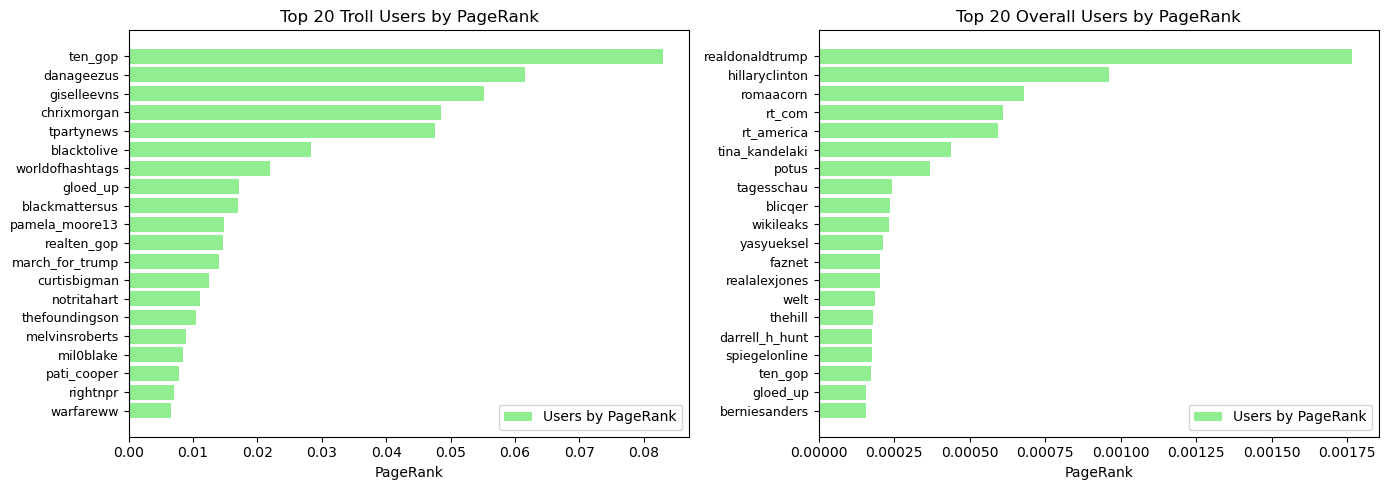

In [40]:
plot_top_users_bar_charts(G_trolls, G_overall, top_n=20)

In [41]:
def plot_top_weight_edges(G_trolls, G_overall, top_n=20):

    # Get top edges
    trolls_edges = []
    for u, v, data in G_trolls.edges(data=True):
        weight = data.get('weight')
        trolls_edges.append((u, v, weight))

    trolls_edges.sort(key=lambda x: x[2], reverse=True)
    trolls_edges = trolls_edges[:top_n]

    overall_edges = []
    for u, v, data in G_overall.edges(data=True):
        weight = data.get('weight')
        overall_edges.append((u, v, weight))

    overall_edges.sort(key=lambda x: x[2], reverse=True)
    overall_edges = overall_edges[:top_n]

    # plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    edge_labels_t = [f"{u} -> {v}" for u, v, w in trolls_edges]
    weights_t = [w for u, v, w in trolls_edges]

    axes[0].barh(range(len(edge_labels_t)), weights_t, color='salmon')
    axes[0].set_yticks(range(len(edge_labels_t)))
    axes[0].set_yticklabels(edge_labels_t, fontsize=9)
    axes[0].set_xlabel('Weight')
    axes[0].set_title(f'Top {top_n} Edges by Weight (Trolls Graph)')
    axes[0].invert_yaxis()
    axes[0].legend(['Edge Weight'], loc='lower right')

    # Overall graph plot
    edge_labels_o = [f"{u} -> {v}" for u, v, w in overall_edges]
    weights_o = [w for u, v, w in overall_edges]

    axes[1].barh(range(len(edge_labels_o)), weights_o, color='steelblue')
    axes[1].set_yticks(range(len(edge_labels_o)))
    axes[1].set_yticklabels(edge_labels_o, fontsize=9)
    axes[1].set_xlabel('Weight')
    axes[1].set_title(f'Top {top_n} Edges by Weight (Overall Graph)')
    axes[1].invert_yaxis()
    axes[1].legend(['Edge Weight'], loc='lower right')

    plt.tight_layout()
    plt.savefig(f'mentions_results/top_{top_n}_edges_by_weight.png', dpi=300, bbox_inches='tight')
    plt.show()

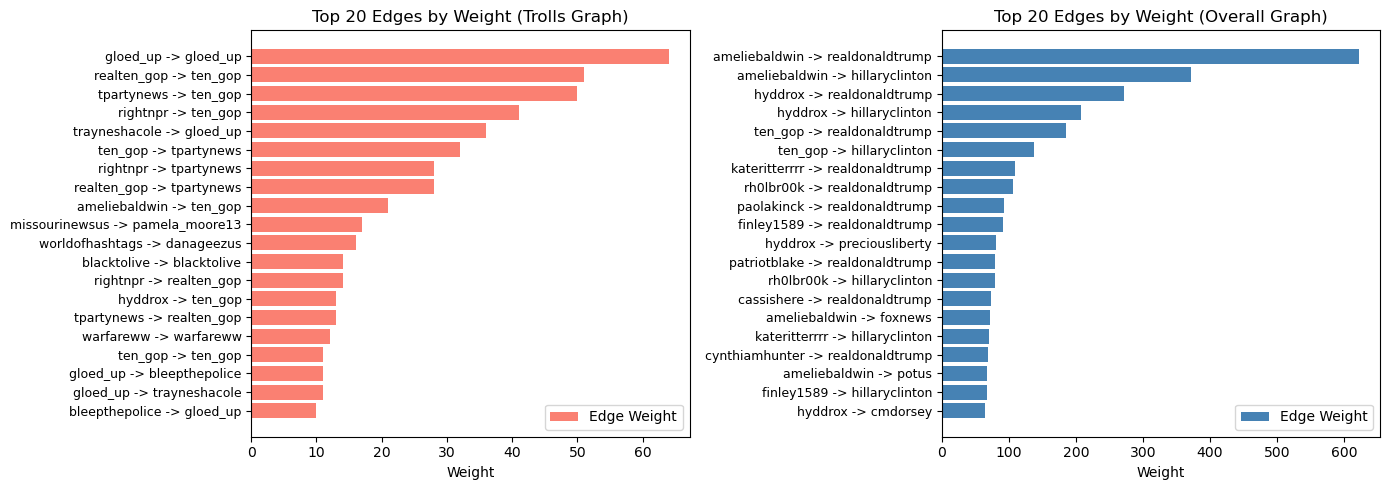

In [42]:
plot_top_weight_edges(G_trolls, G_overall, top_n=20)